# 02 — Playback Rate & Pitch

**Level:** Beginner → Intermediate

The oldest sampler trick: play the buffer **faster** → higher pitch and shorter duration; **slower** → lower and longer. Chromatic mapping uses the twelfth-root-of-two:

$$
\text{rate} = 2^{n/12}
$$

for $n$ semitones away from the sample’s root note.

## Setup

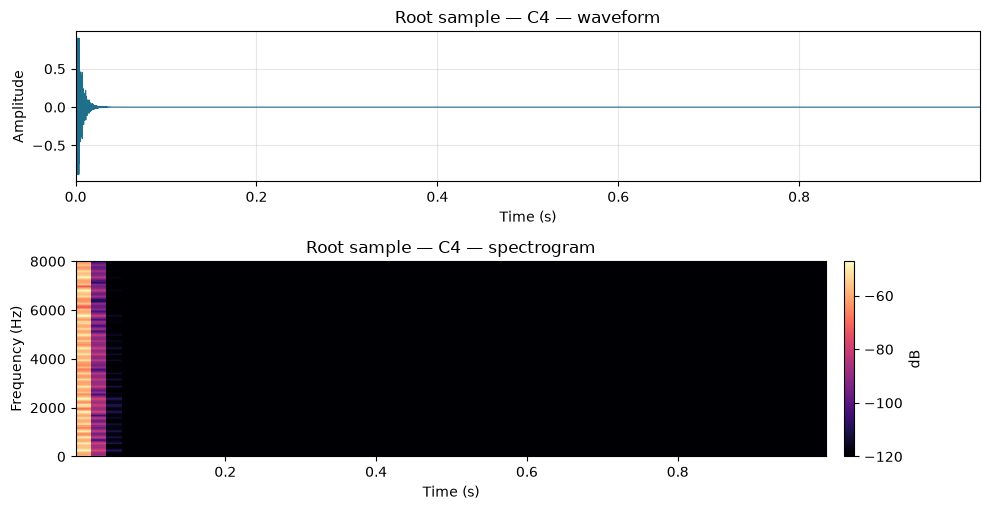

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from audio_utils import (
    SR, hear, normalize, seconds, midi_to_hz, semitone_ratio,
    linear_resample, apply_adsr, plot_waveform,
)

def make_pluck(midi=60, dur=1.0, brightness=0.55, seed=0):
    freq = midi_to_hz(midi)
    n = seconds(dur)
    delay = max(2, int(round(SR / freq)))
    rng = np.random.default_rng(seed + midi)
    buf = rng.uniform(-1, 1, delay)
    out = np.zeros(n)
    idx = 0
    for i in range(n):
        out[i] = buf[idx]
        buf[idx] = brightness * 0.5 * (buf[idx] + buf[(idx + 1) % delay])
        idx = (idx + 1) % delay
    return apply_adsr(normalize(out), attack=0.002, decay=0.04, sustain=0.5, release=0.3)

root = make_pluck(60)
hear(root, SR, title="Root sample — C4", show_spec=True)

## Rate ↔ semitones

Listen to +12 (one octave up: twice as fast) and −12 (half speed). Duration halves / doubles with pitch — classic sampler behavior (no independent time-stretch yet).

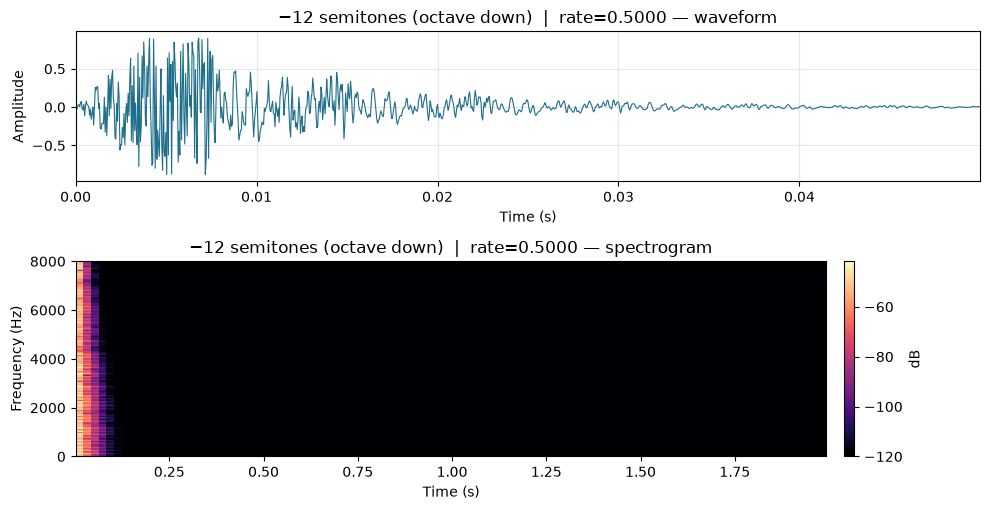

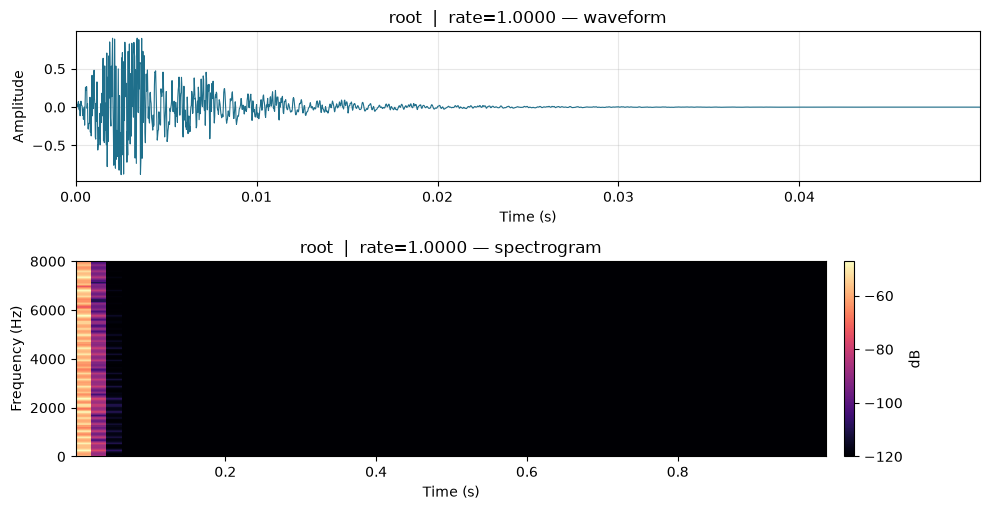

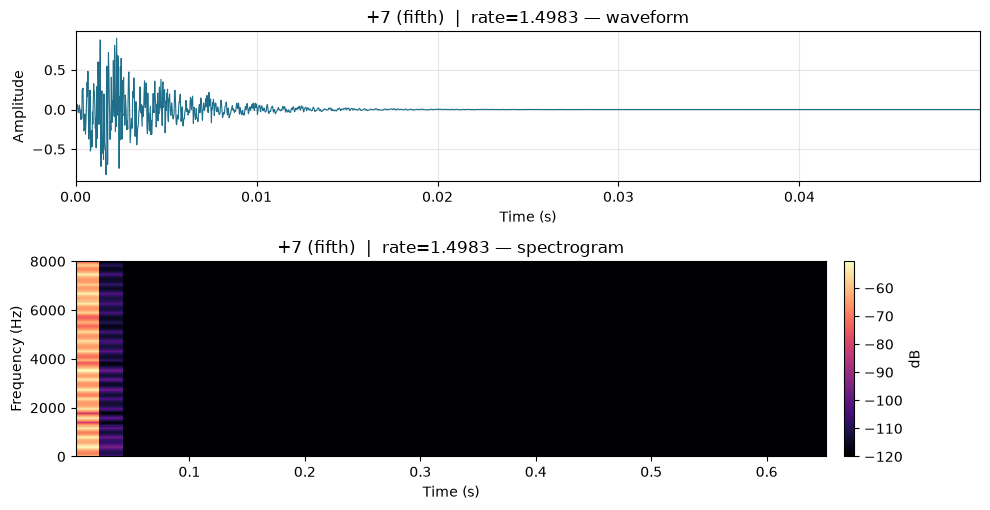

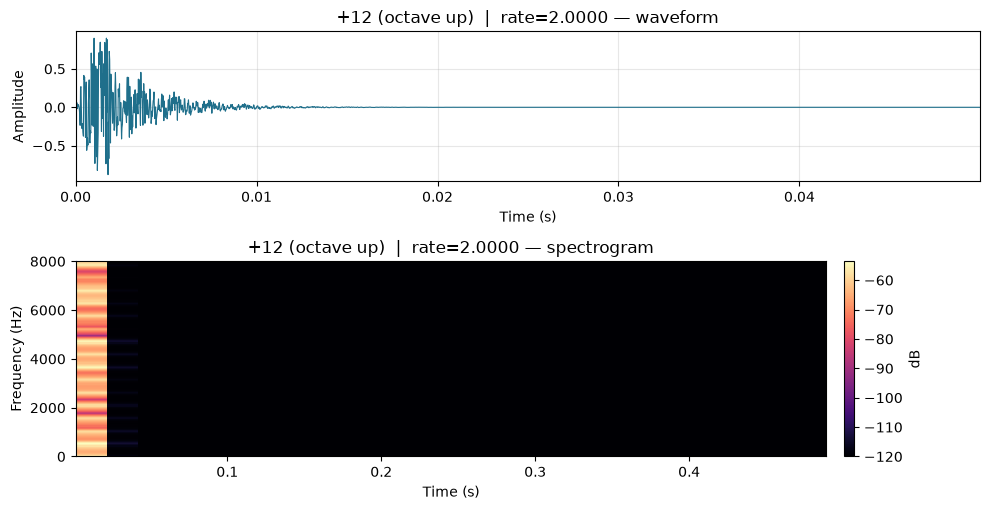

In [2]:
for semis, label in [(-12, "−12 semitones (octave down)"), (0, "root"), (7, "+7 (fifth)"), (12, "+12 (octave up)")]:
    rate = semitone_ratio(semis)
    pitched = linear_resample(root, rate)
    hear(pitched, SR, title=f"{label}  |  rate={rate:.4f}", show_spec=True, max_waveform_seconds=0.05)

## Duration trade-off

Plot length vs. transposition. This is why multisampling exists: stretch a single sample too far and it sounds chipmunked or muddy.

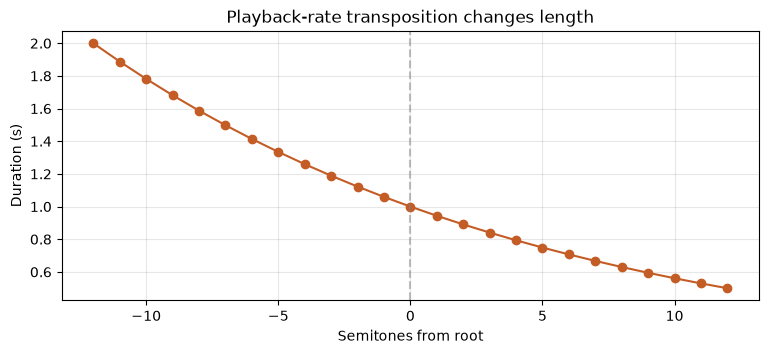

In [3]:
semis = np.arange(-12, 13)
durs = [len(linear_resample(root, semitone_ratio(n))) / SR for n in semis]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(semis, durs, marker="o", color="#c45c26")
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Semitones from root")
ax.set_ylabel("Duration (s)")
ax.set_title("Playback-rate transposition changes length")
ax.grid(True, alpha=0.3)
plt.show()

## Chromatic one-shot sampler

Map MIDI notes to rates relative to root MIDI 60 (C4). Play a short ascending phrase.

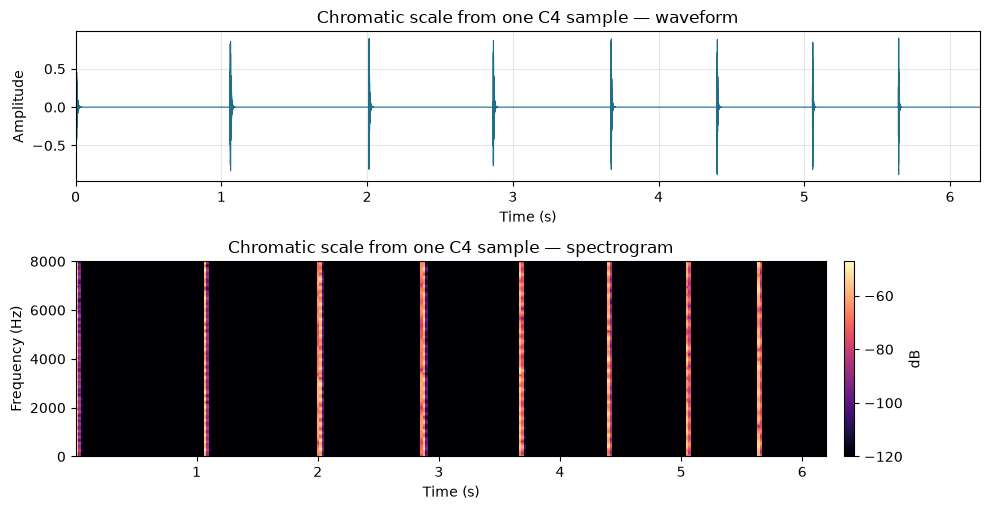

In [4]:
def play_note(sample, root_midi, note_midi, gain=0.9):
    rate = semitone_ratio(note_midi - root_midi)
    return gain * linear_resample(sample, rate)

def sequence(sample, root_midi, notes, gap=0.05):
    parts = []
    silence = np.zeros(seconds(gap))
    for n in notes:
        parts.append(play_note(sample, root_midi, n))
        parts.append(silence)
    return normalize(np.concatenate(parts))

phrase = sequence(root, 60, [60, 62, 64, 65, 67, 69, 71, 72], gap=0.06)
hear(phrase, SR, title="Chromatic scale from one C4 sample", show_spec=True, max_waveform_seconds=None)

## Extreme stretch (when one sample isn’t enough)

± an octave already strains a single recording. Listen for the “chipmunk” formant shift upward — pitch and spectral envelope move together under rate change.

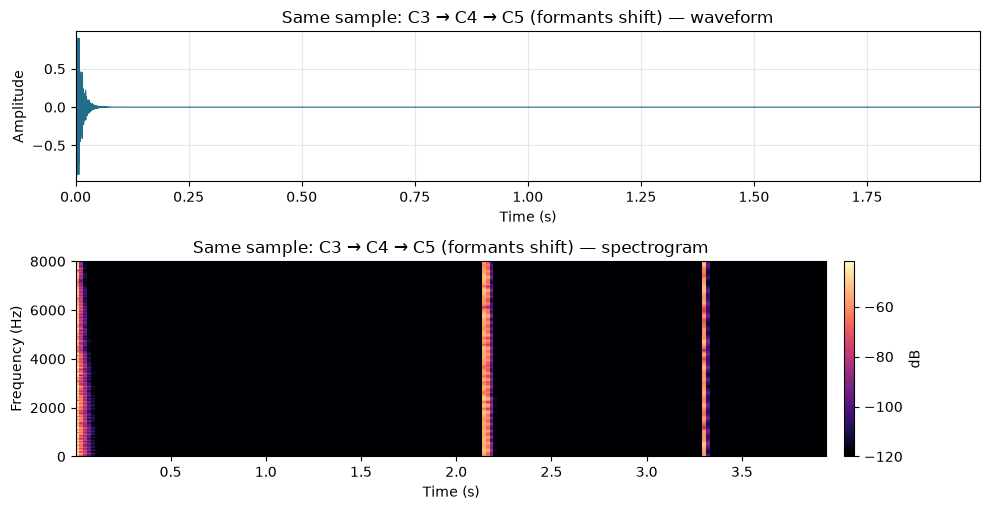

In [5]:
wide = sequence(root, 60, [48, 60, 72], gap=0.15)
hear(wide, SR, title="Same sample: C3 → C4 → C5 (formants shift)", show_spec=True)

## You should be able to…

- Convert semitones to a playback-rate factor
- Explain why pitch-by-rate also changes duration and formants
- Build a tiny chromatic mapper from one root sample

**Next:** [03 — Envelopes, loops & zones](03_envelopes_loops_and_zones.ipynb)